# STEP 4.1.3: SARIMA/SARIMAX Modeling for Inflation Forecasting

Notebook này xây dựng mô hình **SARIMA/SARIMAX** cho dự báo lạm phát, ưu tiên biến mục tiêu `cpi_mom`.

## Nội dung chính

1. Load dữ liệu đã làm sạch.
2. Phân tích mùa vụ và tính dừng của biến mục tiêu.
3. Chọn biến ngoại sinh cho SARIMAX bằng lag correlation và tương quan với target.
4. Biến đổi biến ngoại sinh về dạng phù hợp: `log_diff`, `diff`, hoặc giữ level nếu dừng.
5. Chia train/test theo thời gian.
6. Grid search tối ưu `(p,d,q)(P,D,Q,12)` cho SARIMA và SARIMAX.
7. Train mô hình tốt nhất.
8. Đánh giá trên test set: RMSE, MAE, MAPE, R2, so sánh Random Walk và Mean Forecast.
9. Kiểm định residual: Ljung-Box, Jarque-Bera, ARCH, ACF residual.
10. Nếu mô hình đạt kết quả tốt, vẽ dự báo tương lai kèm khoảng tin cậy.

## Lưu ý

- SARIMA dùng duy nhất biến mục tiêu.
- SARIMAX bổ sung biến ngoại sinh đã được chọn và biến đổi.
- Tất cả thao tác chọn tham số và fit mô hình được thực hiện trên tập train để hạn chế leakage.

## 1. Setup and Configuration

In [20]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import jarque_bera
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_squared_error, mean_absolute_error

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

SCRIPT_DIR = os.getcwd()
DATA_DIR = os.path.join(SCRIPT_DIR, 'data', 'processed')
OUTPUT_DIR = os.path.join(SCRIPT_DIR, 'outputs', 'step4_sarimax')
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"Data Directory  : {DATA_DIR}")
print(f"Output Directory: {OUTPUT_DIR}")

Data Directory  : d:\Nam4-HK1\KLTN\Vietnam_economic_lakehouse\model_test\data\processed
Output Directory: d:\Nam4-HK1\KLTN\Vietnam_economic_lakehouse\model_test\outputs\step4_sarimax


## 2. Load Data

In [21]:
cleaned_data = pd.read_csv(os.path.join(DATA_DIR, 'step1_cleaned_data.csv'))
cleaned_data['date'] = pd.to_datetime(cleaned_data['date'])
cleaned_data = cleaned_data.sort_values('date').reset_index(drop=True)

print(f"Loaded cleaned data: {cleaned_data.shape[0]} rows × {cleaned_data.shape[1]} columns")
print(f"Date range: {cleaned_data['date'].min().date()} to {cleaned_data['date'].max().date()}")
print(f"Missing values: {cleaned_data.isnull().sum().sum()}")
print(cleaned_data.head().to_string(index=False))

Loaded cleaned data: 95 rows × 31 columns
Date range: 2018-06-01 to 2026-04-01
Missing values: 0
      date  cpi_mom  core_inflation_rate  cpi_base_year  interest_rate_last  ppi_qoq        m2  brent_last  wti_last  gasoline_last  gasoline_world_last  natural_gas_last   gold_last  silver_last  VNINDEX_last  VN30_last  HNX_last  UPCOM_last  NASDAQ_last  S&P500_last     DAX_last  DOWJONES_last  NIKKEI225_last  HANGSENG_last  USDVND_last  year  month  quarter  shock_2020-03  shock_2022-02  shock_2023-03
2018-06-01   100.61                 1.37         159.11                3.22     0.51 8879582.0   79.440002     72.46        18450.0               1.4334             2.924 1251.300049       16.104        960.78     947.55    106.17       51.97  7510.299805  2718.370117 12306.000000   24271.410156    22304.509766   28955.109375      22956.0  2018      6        2              0              0              0
2018-07-01    99.91                 1.41         159.11                3.22     1.08 88

## 3. Select Target and Candidate Exogenous Variables

In [22]:
target_var = 'cpi_mom'

if target_var not in cleaned_data.columns:
    raise ValueError(f"Target variable {target_var} not found in cleaned_data")

candidate_exog_vars = [
    'm2',
    'core_inflation_rate',
    'cpi_base_year',
    'interest_rate_last',
    'ppi_qoq',
    'brent_last',
    'wti_last',
    'gasoline_last',
    'gasoline_world_last',
    'natural_gas_last',
    'gold_last',
    'silver_last',
    'VNINDEX_last',
    'VN30_last',
    'HNX_last',
    'UPCOM_last',
    'S&P500_last',
    'NASDAQ_last',
    'DAX_last',
    'USDVND_last',
    'shock_2020-03',
    'shock_2022-02',
    'shock_2023-03',
    'month',
    'quarter'
]

candidate_exog_vars = [v for v in candidate_exog_vars if v in cleaned_data.columns]

# Build time-indexed dataframe.
df = cleaned_data[['date', target_var] + candidate_exog_vars].copy()
df = df.dropna().sort_values('date').reset_index(drop=True)
df = df.set_index('date')

# Enforce monthly frequency when possible.
df = df.asfreq('MS')
df = df.ffill().bfill()

print("Target:", target_var)
print("Candidate exogenous variables:")
print(candidate_exog_vars)
print("Dataset shape:", df.shape)
print("Index frequency:", df.index.freq)

Target: cpi_mom
Candidate exogenous variables:
['m2', 'core_inflation_rate', 'cpi_base_year', 'interest_rate_last', 'ppi_qoq', 'brent_last', 'wti_last', 'gasoline_last', 'gasoline_world_last', 'natural_gas_last', 'gold_last', 'silver_last', 'VNINDEX_last', 'VN30_last', 'HNX_last', 'UPCOM_last', 'S&P500_last', 'NASDAQ_last', 'DAX_last', 'USDVND_last', 'shock_2020-03', 'shock_2022-02', 'shock_2023-03', 'month', 'quarter']
Dataset shape: (95, 26)
Index frequency: <MonthBegin>


## 4. Stationarity Tests for Target

In [23]:
def adf_pvalue(series):
    series = pd.Series(series).dropna()
    try:
        return adfuller(series, autolag='AIC')[1]
    except Exception:
        return np.nan


def kpss_pvalue(series):
    series = pd.Series(series).dropna()
    try:
        return kpss(series, regression='c', nlags='auto')[1]
    except Exception:
        return np.nan


y = df[target_var].astype(float)
adf_p = adf_pvalue(y)
kpss_p = kpss_pvalue(y)

print("Stationarity tests for target:")
print(f"ADF p-value : {adf_p:.6f}  | H0: non-stationary")
print(f"KPSS p-value: {kpss_p:.6f} | H0: stationary")

if adf_p < 0.05 and kpss_p > 0.05:
    suggested_d = 0
    print("Suggested d = 0 because target appears stationary I(0).")
else:
    suggested_d = 1
    print("Suggested d = 1 because target may be non-stationary or mixed.")

Stationarity tests for target:
ADF p-value : 0.000000  | H0: non-stationary
KPSS p-value: 0.100000 | H0: stationary
Suggested d = 0 because target appears stationary I(0).


## 5. Seasonality Analysis

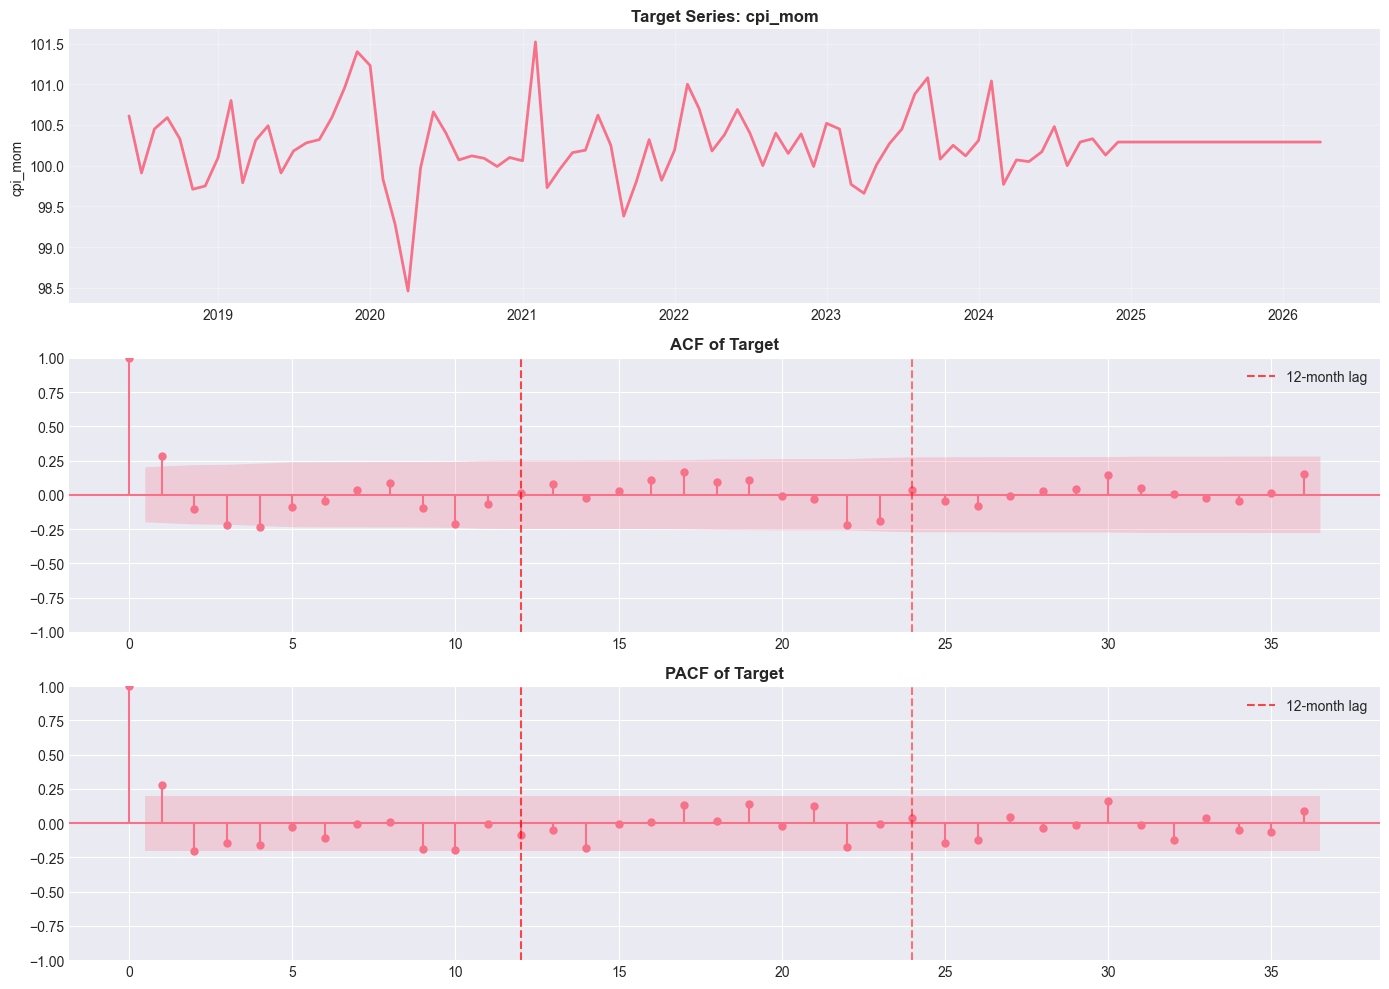

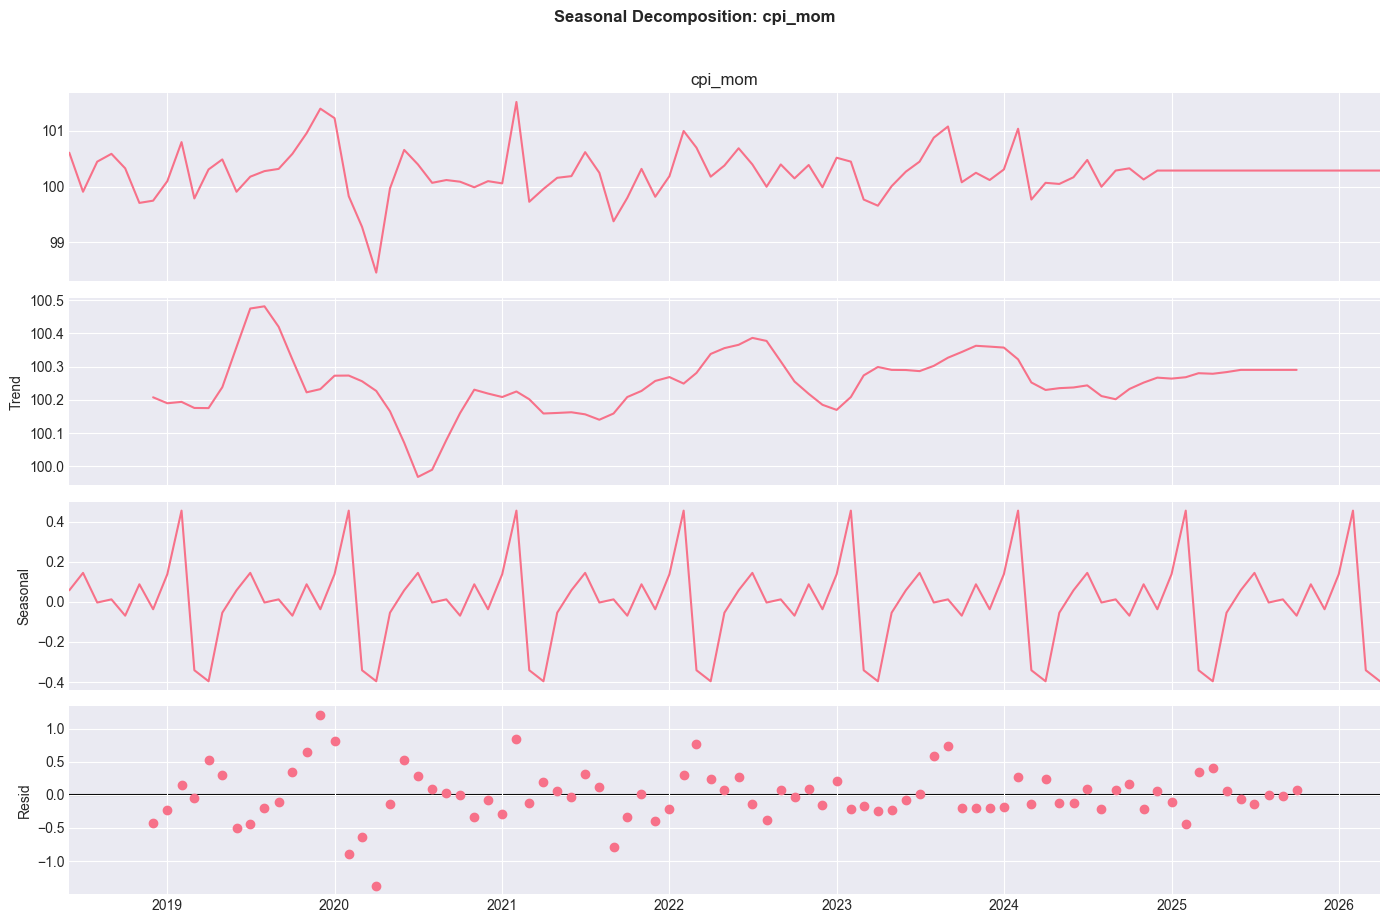

Trend strength   : 0.0481
Seasonal strength: 0.2337


In [24]:
SEASONAL_PERIOD = 12

fig, axes = plt.subplots(3, 1, figsize=(14, 10))

axes[0].plot(y.index, y.values, linewidth=2)
axes[0].set_title(f'Target Series: {target_var}', fontweight='bold')
axes[0].set_ylabel(target_var)
axes[0].grid(True, alpha=0.3)

plot_acf(y.dropna(), lags=min(36, len(y)//2), ax=axes[1])
axes[1].axvline(SEASONAL_PERIOD, color='red', linestyle='--', alpha=0.7, label='12-month lag')
axes[1].axvline(SEASONAL_PERIOD*2, color='red', linestyle='--', alpha=0.5)
axes[1].set_title('ACF of Target', fontweight='bold')
axes[1].legend()

plot_pacf(y.dropna(), lags=min(36, len(y)//2 - 1), ax=axes[2], method='ywm')
axes[2].axvline(SEASONAL_PERIOD, color='red', linestyle='--', alpha=0.7, label='12-month lag')
axes[2].axvline(SEASONAL_PERIOD*2, color='red', linestyle='--', alpha=0.5)
axes[2].set_title('PACF of Target', fontweight='bold')
axes[2].legend()

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'target_acf_pacf_seasonality.png'), dpi=150)
plt.show()

# Seasonal decomposition.
try:
    decomposition = seasonal_decompose(y, model='additive', period=SEASONAL_PERIOD)
    fig = decomposition.plot()
    fig.set_size_inches(14, 9)
    fig.suptitle(f'Seasonal Decomposition: {target_var}', fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'seasonal_decomposition.png'), dpi=150)
    plt.show()

    trend_var = decomposition.trend.var()
    seas_var = decomposition.seasonal.var()
    resid_var = decomposition.resid.var()

    trend_strength = trend_var / (trend_var + resid_var) if (trend_var + resid_var) > 0 else np.nan
    seasonal_strength = seas_var / (seas_var + resid_var) if (seas_var + resid_var) > 0 else np.nan

    print(f"Trend strength   : {trend_strength:.4f}")
    print(f"Seasonal strength: {seasonal_strength:.4f}")
except Exception as e:
    print("Seasonal decomposition failed:", e)

## 6. Transform Exogenous Variables

In [25]:
def classify_stationarity(series):
    a = adf_pvalue(series)
    k = kpss_pvalue(series)
    if pd.notna(a) and pd.notna(k) and a < 0.05 and k > 0.05:
        return 'I(0)', a, k
    if pd.notna(a) and a > 0.05:
        return 'Non-stationary', a, k
    return 'Mixed/unclear', a, k


df_model = pd.DataFrame(index=df.index)
df_model[target_var] = df[target_var].astype(float)

transform_rows = []
exog_transformed_cols = []

for col in candidate_exog_vars:
    if col == target_var:
        continue

    s = df[col].astype(float)

    # Keep dummies and calendar variables in level.
    if col.startswith('shock_') or col in ['month', 'quarter']:
        new_col = col
        df_model[new_col] = s
        method = 'level_calendar_or_dummy'
        status, adf_before, kpss_before = 'not_tested', np.nan, np.nan
        adf_after, kpss_after = np.nan, np.nan
    else:
        status, adf_before, kpss_before = classify_stationarity(s)
        if status == 'I(0)':
            new_col = col
            df_model[new_col] = s
            method = 'level_I0'
            adf_after, kpss_after = adf_before, kpss_before
        else:
            if (s > 0).all():
                new_col = f'dlog_{col}'
                df_model[new_col] = np.log(s).diff()
                method = 'log_diff'
            else:
                new_col = f'diff_{col}'
                df_model[new_col] = s.diff()
                method = 'diff'
            adf_after = adf_pvalue(df_model[new_col])
            kpss_after = kpss_pvalue(df_model[new_col])

    exog_transformed_cols.append(new_col)
    transform_rows.append({
        'Original': col,
        'Transformed': new_col,
        'Method': method,
        'Status_before': status,
        'ADF_before': adf_before,
        'KPSS_before': kpss_before,
        'ADF_after': adf_after,
        'KPSS_after': kpss_after
    })

transform_df = pd.DataFrame(transform_rows)
print(transform_df.to_string(index=False))

# Drop NA caused by differencing.
df_model = df_model.dropna()

print("Model-ready dataset shape:", df_model.shape)
print("Columns:", df_model.columns.tolist())

           Original              Transformed                  Method  Status_before  ADF_before  KPSS_before    ADF_after  KPSS_after
                 m2                  diff_m2                    diff Non-stationary    0.549128     0.100000 1.310289e-16    0.100000
core_inflation_rate dlog_core_inflation_rate                log_diff Non-stationary    0.259247     0.020770 1.062881e-15    0.100000
      cpi_base_year       dlog_cpi_base_year                log_diff Non-stationary    0.526116     0.010000 7.342403e-01    0.100000
 interest_rate_last  dlog_interest_rate_last                log_diff Non-stationary    0.354678     0.083264 1.147440e-01    0.100000
            ppi_qoq             diff_ppi_qoq                    diff Non-stationary    0.127786     0.100000 2.466243e-08    0.100000
         brent_last          dlog_brent_last                log_diff Non-stationary    0.185360     0.056260 7.627906e-15    0.100000
           wti_last            dlog_wti_last                lo

## 7. Exogenous Variable Selection for SARIMAX

In [26]:
def max_abs_lag_corr(df_input, target, feature, max_lag=12):
    best_corr = np.nan
    best_lag = None
    for lag in range(0, max_lag + 1):
        if lag == 0:
            corr = df_input[target].corr(df_input[feature])
        else:
            corr = df_input[target].corr(df_input[feature].shift(lag))
        if pd.notna(corr):
            if pd.isna(best_corr) or abs(corr) > abs(best_corr):
                best_corr = corr
                best_lag = lag
    return best_corr, best_lag

selection_rows = []
for col in exog_transformed_cols:
    # Skip calendar and shock variables - use only economic/financial features
    if col.startswith('shock_') or col in ['month', 'quarter']:
        continue
    if col not in df_model.columns or col == target_var:
        continue
    corr0 = df_model[target_var].corr(df_model[col])
    lagcorr, best_lag = max_abs_lag_corr(df_model, target_var, col, max_lag=12)
    selection_rows.append({
        'Feature': col,
        'Corr_lag0': corr0,
        'Max_abs_lag_corr': lagcorr,
        'Best_lag': best_lag,
        'abs_Max_corr': abs(lagcorr) if pd.notna(lagcorr) else np.nan
    })

selection_df = pd.DataFrame(selection_rows).sort_values('abs_Max_corr', ascending=False)
print(selection_df.to_string(index=False))

# Build exog sets: top features + theory-based features.
top3_exog = selection_df.head(3)['Feature'].tolist()
top5_exog = selection_df.head(5)['Feature'].tolist()

preferred_patterns = ['m2', 'USDVND', 'interest_rate', 'brent', 'gasoline', 'ppi']
theory_exog = []
for pattern in preferred_patterns:
    matches = [c for c in df_model.columns if c != target_var and pattern.lower() in c.lower() and not c.startswith('shock_')]
    if matches:
        theory_exog.append(matches[0])
theory_exog = list(dict.fromkeys(theory_exog))[:5]

exog_sets = {
    'SARIMA_no_exog': [],
    'SARIMAX_top3': top3_exog,
    'SARIMAX_top5': top5_exog,
    'SARIMAX_theory': theory_exog
}

print("\nExogenous sets (economic/financial features only):")
for name, cols in exog_sets.items():
    print(f"{name:20} : {cols}")

                 Feature  Corr_lag0  Max_abs_lag_corr  Best_lag  abs_Max_corr
         dlog_brent_last   0.190762          0.508315         1      0.508315
           dlog_wti_last   0.194751          0.500206         1      0.500206
dlog_core_inflation_rate   0.374171          0.374171         0      0.374171
      dlog_cpi_base_year   0.112071         -0.304390         3      0.304390
        dlog_S&P500_last  -0.044978         -0.245821         5      0.245821
        dlog_NASDAQ_last  -0.042913         -0.241788         5      0.241788
dlog_gasoline_world_last  -0.060983         -0.238556         8      0.238556
            diff_ppi_qoq   0.086328          0.232170         7      0.232170
           dlog_DAX_last  -0.035002         -0.231041         4      0.231041
       dlog_VNINDEX_last  -0.025166          0.224831         2      0.224831
          dlog_gold_last  -0.119880          0.214566         7      0.214566
 dlog_interest_rate_last   0.049331         -0.208703         4 

## 8. Train/Test Split

In [27]:
TEST_RATIO = 0.2
n_obs = len(df_model)
train_size = int(n_obs * (1 - TEST_RATIO))

y_all = df_model[target_var]
y_train = y_all.iloc[:train_size]
y_test = y_all.iloc[train_size:]

print(f"Total observations: {n_obs}")
print(f"Train observations: {len(y_train)} | {y_train.index.min().date()} to {y_train.index.max().date()}")
print(f"Test observations : {len(y_test)} | {y_test.index.min().date()} to {y_test.index.max().date()}")

Total observations: 94
Train observations: 75 | 2018-07-01 to 2024-09-01
Test observations : 19 | 2024-10-01 to 2026-04-01


## 9. Grid Search for SARIMA/SARIMAX Parameters

In [28]:
# Parameter grids. Keep compact for monthly data and small sample.
p_values = [0, 1, 2]
d_values = [suggested_d] if suggested_d in [0, 1] else [0, 1]
q_values = [0, 1, 2]

P_values = [0, 1]
D_values = [0]
Q_values = [0, 1]
s = 12

MAX_MODELS_PER_EXOG_SET = None  # Set an integer for faster testing if needed.

def fit_sarimax_safe(y_train, exog_train, order, seasonal_order):
    try:
        model = SARIMAX(
            y_train,
            exog=exog_train,
            order=order,
            seasonal_order=seasonal_order,
            enforce_stationarity=False,
            enforce_invertibility=False
        )
        res = model.fit(disp=False, maxiter=300)
        return res, None
    except Exception as e:
        return None, str(e)

grid_results = []
fitted_grid_models = {}

for exog_name, exog_cols in exog_sets.items():
    print("" + "=" * 100)
    print(f"GRID SEARCH: {exog_name}")
    print("Exog:", exog_cols)
    print("=" * 100)

    if len(exog_cols) == 0:
        exog_train = None
    else:
        exog_train = df_model[exog_cols].iloc[:train_size]

    count = 0

    for p in p_values:
        for d in d_values:
            for q in q_values:
                for P in P_values:
                    for D in D_values:
                        for Q in Q_values:
                            order = (p, d, q)
                            seasonal_order = (P, D, Q, s)

                            # Avoid all-zero non-seasonal and seasonal with unnecessary complexity not issue; keep allowed.
                            res, err = fit_sarimax_safe(y_train, exog_train, order, seasonal_order)

                            if res is not None:
                                key = f"{exog_name}_{order}_{seasonal_order}"
                                fitted_grid_models[key] = res
                                grid_results.append({
                                    'exog_set': exog_name,
                                    'exog_cols': exog_cols,
                                    'order': order,
                                    'seasonal_order': seasonal_order,
                                    'AIC': res.aic,
                                    'BIC': res.bic,
                                    'HQIC': res.hqic,
                                    'llf': res.llf,
                                    'key': key
                                })
                                count += 1

                            if MAX_MODELS_PER_EXOG_SET is not None and count >= MAX_MODELS_PER_EXOG_SET:
                                break
                        if MAX_MODELS_PER_EXOG_SET is not None and count >= MAX_MODELS_PER_EXOG_SET:
                            break
                    if MAX_MODELS_PER_EXOG_SET is not None and count >= MAX_MODELS_PER_EXOG_SET:
                        break
                if MAX_MODELS_PER_EXOG_SET is not None and count >= MAX_MODELS_PER_EXOG_SET:
                    break
            if MAX_MODELS_PER_EXOG_SET is not None and count >= MAX_MODELS_PER_EXOG_SET:
                break
        if MAX_MODELS_PER_EXOG_SET is not None and count >= MAX_MODELS_PER_EXOG_SET:
            break

    print(f"Valid models fitted: {count}")

grid_results_df = pd.DataFrame(grid_results)

print("" + "=" * 100)
print("TOP MODELS BY AIC")
print("=" * 100)
if not grid_results_df.empty:
    print(grid_results_df.sort_values('AIC').head(15).to_string(index=False))
else:
    print("No valid SARIMA/SARIMAX models found.")

GRID SEARCH: SARIMA_no_exog
Exog: []
Valid models fitted: 36
GRID SEARCH: SARIMAX_top3
Exog: ['dlog_brent_last', 'dlog_wti_last', 'dlog_core_inflation_rate']
Valid models fitted: 36
GRID SEARCH: SARIMAX_top5
Exog: ['dlog_brent_last', 'dlog_wti_last', 'dlog_core_inflation_rate', 'dlog_cpi_base_year', 'dlog_S&P500_last']
Valid models fitted: 36
GRID SEARCH: SARIMAX_theory
Exog: ['diff_m2', 'dlog_USDVND_last', 'dlog_interest_rate_last', 'dlog_brent_last', 'dlog_gasoline_last']
Valid models fitted: 36
TOP MODELS BY AIC
      exog_set                                                  exog_cols     order seasonal_order       AIC        BIC       HQIC        llf                                    key
  SARIMAX_top3 [dlog_brent_last, dlog_wti_last, dlog_core_inflation_rate] (2, 0, 0)  (1, 0, 1, 12) 75.911273  92.798264  82.529443 -29.955636   SARIMAX_top3_(2, 0, 0)_(1, 0, 1, 12)
  SARIMAX_top3 [dlog_brent_last, dlog_wti_last, dlog_core_inflation_rate] (1, 0, 0)  (1, 0, 1, 12) 81.641370  96.5313

## 10. Evaluate Top Models on Test Set

In [29]:
def forecast_metrics(actual, predicted):
    actual = np.asarray(actual)
    predicted = np.asarray(predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mae = mean_absolute_error(actual, predicted)
    mask = actual != 0
    mape = np.mean(np.abs((actual[mask] - predicted[mask]) / actual[mask])) * 100 if np.any(mask) else np.nan
    ss_res = np.sum((actual - predicted) ** 2)
    ss_tot = np.sum((actual - np.mean(actual)) ** 2)
    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan
    return rmse, mae, mape, r2


def evaluate_fitted_model(row):
    res = fitted_grid_models[row['key']]
    exog_cols = row['exog_cols']

    if len(exog_cols) == 0:
        exog_test = None
    else:
        exog_test = df_model[exog_cols].iloc[train_size:]

    try:
        pred_res = res.get_forecast(steps=len(y_test), exog=exog_test)
        pred_mean = pred_res.predicted_mean
        pred_ci = pred_res.conf_int(alpha=0.05)

        rmse, mae, mape, r2 = forecast_metrics(y_test.values, pred_mean.values)

        rw_pred = np.repeat(y_train.iloc[-1], len(y_test))
        mean_pred = np.repeat(y_train.mean(), len(y_test))
        rmse_rw, _, _, _ = forecast_metrics(y_test.values, rw_pred)
        rmse_mean, _, _, _ = forecast_metrics(y_test.values, mean_pred)

        ss_res = np.sum((y_test.values - pred_mean.values) ** 2)
        ss_rw = np.sum((y_test.values - rw_pred) ** 2)
        r2_vs_rw = 1 - ss_res / ss_rw if ss_rw > 0 else np.nan

        return {
            'status': 'success',
            'RMSE': rmse,
            'MAE': mae,
            'MAPE': mape,
            'R2_testmean': r2,
            'RMSE_RW': rmse_rw,
            'RMSE_Mean': rmse_mean,
            'Model_vs_RW': rmse / rmse_rw if rmse_rw > 0 else np.nan,
            'Model_vs_Mean': rmse / rmse_mean if rmse_mean > 0 else np.nan,
            'R2_vs_RW': r2_vs_rw,
            'pred_mean': pred_mean,
            'pred_ci': pred_ci
        }
    except Exception as e:
        return {'status': 'failed', 'error': str(e)}

# Evaluate top N by AIC and BIC.
TOP_N = 30
candidate_rows = grid_results_df.copy()

eval_rows = []
eval_objects = {}

for _, row in candidate_rows.iterrows():
    out = evaluate_fitted_model(row)
    if out['status'] == 'success':
        eval_row = row.to_dict()
        eval_row.update({
            'RMSE': out['RMSE'],
            'MAE': out['MAE'],
            'MAPE': out['MAPE'],
            'R2_testmean': out['R2_testmean'],
            'RMSE_RW': out['RMSE_RW'],
            'RMSE_Mean': out['RMSE_Mean'],
            'Model_vs_RW': out['Model_vs_RW'],
            'Model_vs_Mean': out['Model_vs_Mean'],
            'R2_vs_RW': out['R2_vs_RW']
        })
        eval_rows.append(eval_row)
        eval_objects[row['key']] = out

model_eval_df = pd.DataFrame(eval_rows)

print("=" * 100)
print("MODEL EVALUATION ON TEST SET")
print("=" * 100)
if not model_eval_df.empty:
    model_eval_df = model_eval_df.sort_values('RMSE')
    display_cols = ['exog_set', 'order', 'seasonal_order', 'AIC', 'BIC', 'RMSE', 'MAE', 'MAPE', 'R2_testmean', 'RMSE_RW', 'Model_vs_RW', 'RMSE_Mean', 'Model_vs_Mean', 'R2_vs_RW', 'key']
    print(model_eval_df[display_cols].head(20).to_string(index=False))
else:
    print("No model evaluation succeeded.")

MODEL EVALUATION ON TEST SET
      exog_set     order seasonal_order        AIC        BIC     RMSE      MAE     MAPE  R2_testmean  RMSE_RW  Model_vs_RW  RMSE_Mean  Model_vs_Mean   R2_vs_RW                                    key
SARIMA_no_exog (2, 0, 2)  (0, 0, 0, 12) 112.001049 123.384380 0.045304 0.036811 0.036717    -0.474761 0.037836     1.197359   0.056739       0.798453  -0.433669 SARIMA_no_exog_(2, 0, 2)_(0, 0, 0, 12)
SARIMA_no_exog (1, 0, 1)  (0, 0, 1, 12)  99.531848 107.975344 0.050671 0.044733 0.044612    -0.844897 0.037836     1.339213   0.056739       0.893048  -0.793491 SARIMA_no_exog_(1, 0, 1)_(0, 0, 1, 12)
SARIMA_no_exog (1, 0, 0)  (1, 0, 0, 12) 113.169121 119.550524 0.051607 0.046069 0.045945    -0.913729 0.037836     1.363967   0.056739       0.909555  -0.860405 SARIMA_no_exog_(1, 0, 0)_(1, 0, 0, 12)
SARIMA_no_exog (1, 0, 2)  (0, 0, 1, 12)  93.002810 103.474533 0.052259 0.047698 0.047569    -0.962341 0.037836     1.381181   0.056739       0.921034  -0.907662 SARIMA_no_

## 11. Fit Final Best Model and Summary

In [30]:
if model_eval_df.empty:
    raise ValueError("No evaluated models available.")

best_row = model_eval_df.iloc[0]
best_key = best_row['key']
best_model = fitted_grid_models[best_key]
best_eval = eval_objects[best_key]

print("=" * 100)
print("BEST SARIMA/SARIMAX MODEL")
print("=" * 100)
print("Exog set       :", best_row['exog_set'])
print("Exog columns   :", best_row['exog_cols'])
print("Order          :", best_row['order'])
print("Seasonal order :", best_row['seasonal_order'])
print(f"AIC            : {best_row['AIC']:.4f}")
print(f"BIC            : {best_row['BIC']:.4f}")
print(f"RMSE           : {best_row['RMSE']:.6f}")
print(f"MAE            : {best_row['MAE']:.6f}")
print(f"R2_testmean    : {best_row['R2_testmean']:.4f}")
print(f"Model_vs_RW    : {best_row['Model_vs_RW']:.4f}")
print(f"R2_vs_RW       : {best_row['R2_vs_RW']:.4f}")
print("Model summary:")
print(best_model.summary())

BEST SARIMA/SARIMAX MODEL
Exog set       : SARIMA_no_exog
Exog columns   : []
Order          : (2, 0, 2)
Seasonal order : (0, 0, 0, 12)
AIC            : 112.0010
BIC            : 123.3844
RMSE           : 0.045304
MAE            : 0.036811
R2_testmean    : -0.4748
Model_vs_RW    : 1.1974
R2_vs_RW       : -0.4337
Model summary:
                               SARIMAX Results                                
Dep. Variable:                cpi_mom   No. Observations:                   75
Model:               SARIMAX(2, 0, 2)   Log Likelihood                 -51.001
Date:                Sun, 17 May 2026   AIC                            112.001
Time:                        20:13:08   BIC                            123.384
Sample:                    07-01-2018   HQIC                           116.533
                         - 09-01-2024                                         
Covariance Type:                  opg                                         
                 coef    std err       

## 12. Plot Actual vs Forecast on Test Set

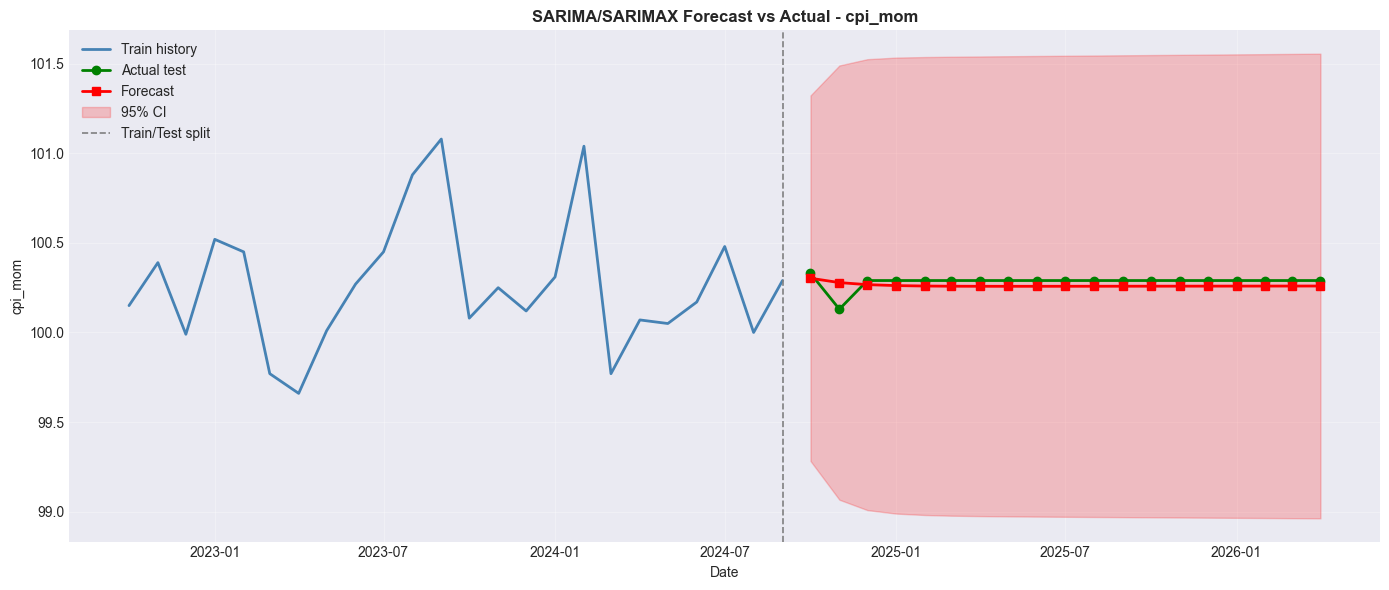

In [31]:
pred_mean = best_eval['pred_mean']
pred_ci = best_eval['pred_ci']

plt.figure(figsize=(14, 6))
plt.plot(y_train.index[-24:], y_train.iloc[-24:], label='Train history', color='steelblue', linewidth=2)
plt.plot(y_test.index, y_test.values, label='Actual test', color='green', linewidth=2, marker='o')
plt.plot(pred_mean.index, pred_mean.values, label='Forecast', color='red', linewidth=2, marker='s')

lower_col = pred_ci.columns[0]
upper_col = pred_ci.columns[1]
plt.fill_between(pred_ci.index, pred_ci[lower_col], pred_ci[upper_col], color='red', alpha=0.2, label='95% CI')
plt.axvline(y_train.index[-1], color='gray', linestyle='--', linewidth=1.2, label='Train/Test split')
plt.title(f'SARIMA/SARIMAX Forecast vs Actual - {target_var}', fontweight='bold')
plt.xlabel('Date')
plt.ylabel(target_var)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'sarimax_test_forecast.png'), dpi=150)
plt.show()

## 13. Residual Diagnostics

RESIDUAL DIAGNOSTICS
Ljung-Box test (H0: no residual autocorrelation):
      lb_stat  lb_pvalue
5   11.343376   0.044981
10  11.357897   0.330323
Jarque-Bera test (H0: residuals are normal):
JB stat: 7853.5474, p-value: 0.0000
ARCH test (H0: no ARCH heteroskedasticity):
ARCH stat: 10.1962, p-value: 0.0699


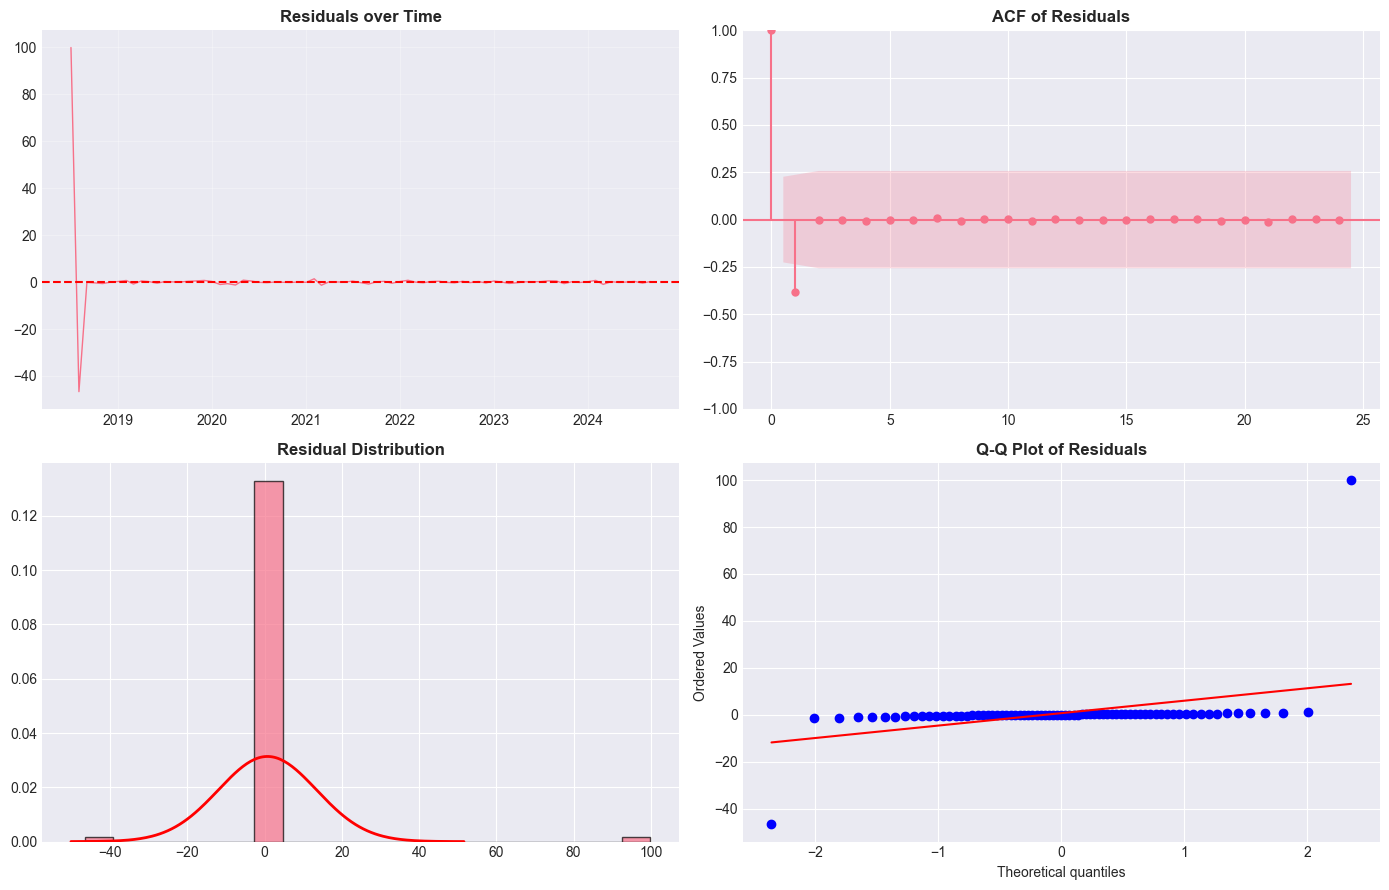

In [32]:
resid = best_model.resid.dropna()

print("=" * 100)
print("RESIDUAL DIAGNOSTICS")
print("=" * 100)

# Ljung-Box test.
lb_lags = [min(5, len(resid)//4), min(10, len(resid)//3)]
lb_lags = sorted(list(set([lag for lag in lb_lags if lag > 0])))
ljung = acorr_ljungbox(resid, lags=lb_lags, return_df=True)
print("Ljung-Box test (H0: no residual autocorrelation):")
print(ljung)

# Jarque-Bera.
jb_stat, jb_p = jarque_bera(resid)
print("Jarque-Bera test (H0: residuals are normal):")
print(f"JB stat: {jb_stat:.4f}, p-value: {jb_p:.4f}")

# ARCH test.
try:
    arch_stat, arch_p, _, _ = het_arch(resid, nlags=min(5, max(1, len(resid)//5)))
    print("ARCH test (H0: no ARCH heteroskedasticity):")
    print(f"ARCH stat: {arch_stat:.4f}, p-value: {arch_p:.4f}")
except Exception as e:
    print("ARCH test failed:", e)

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

axes[0, 0].plot(resid.index, resid.values, linewidth=1)
axes[0, 0].axhline(0, color='red', linestyle='--')
axes[0, 0].set_title('Residuals over Time', fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

plot_acf(resid, lags=min(24, len(resid)//2), ax=axes[0, 1])
axes[0, 1].set_title('ACF of Residuals', fontweight='bold')

axes[1, 0].hist(resid.values, bins=20, density=True, alpha=0.7, edgecolor='black')
mu, sigma = np.mean(resid), np.std(resid)
if sigma > 0:
    x = np.linspace(mu - 4*sigma, mu + 4*sigma, 200)
    axes[1, 0].plot(x, stats.norm.pdf(x, mu, sigma), color='red', linewidth=2)
axes[1, 0].set_title('Residual Distribution', fontweight='bold')

stats.probplot(resid.values, dist='norm', plot=axes[1, 1])
axes[1, 1].set_title('Q-Q Plot of Residuals', fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'sarimax_residual_diagnostics.png'), dpi=150)
plt.show()

## 14. Future Forecast if Model Performance is Acceptable

In [33]:
# Define acceptance rules.
# You can adjust thresholds depending on thesis criteria.
performance_good = (best_row['Model_vs_RW'] < 1) or (best_row['R2_testmean'] > 0)
residual_ok = True
try:
    residual_ok = (ljung['lb_pvalue'].min() > 0.05)
except Exception:
    residual_ok = True

print("Performance good:", performance_good)
print("Residual autocorrelation OK:", residual_ok)

FUTURE_STEPS = 12

if performance_good:
    # Refit best specification on full data, then forecast future.
    exog_cols = best_row['exog_cols']
    order = best_row['order']
    seasonal_order = best_row['seasonal_order']

    y_full = df_model[target_var]

    if len(exog_cols) == 0:
        exog_full = None
        exog_future = None
    else:
        exog_full = df_model[exog_cols]
        # For future exog, use last observed value as a simple baseline scenario.
        # For calendar/month/quarter, generate future values.
        future_index = pd.date_range(start=df_model.index[-1], periods=FUTURE_STEPS + 1, freq='MS')[1:]
        exog_future = pd.DataFrame(index=future_index)
        for col in exog_cols:
            if col == 'month':
                exog_future[col] = future_index.month
            elif col == 'quarter':
                exog_future[col] = future_index.quarter
            elif col.startswith('shock_'):
                exog_future[col] = 0
            else:
                exog_future[col] = exog_full[col].iloc[-1]

    final_model = SARIMAX(
        y_full,
        exog=exog_full,
        order=order,
        seasonal_order=seasonal_order,
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    final_res = final_model.fit(disp=False, maxiter=300)

    future_pred = final_res.get_forecast(steps=FUTURE_STEPS, exog=exog_future)
    future_mean = future_pred.predicted_mean
    future_ci = future_pred.conf_int(alpha=0.05)

    plt.figure(figsize=(14, 6))
    history = y_full.iloc[-36:]
    plt.plot(history.index, history.values, label='Historical', color='steelblue', linewidth=2)
    plt.plot(future_mean.index, future_mean.values, label='Future forecast', color='red', linewidth=2, marker='s')
    plt.fill_between(future_ci.index, future_ci.iloc[:, 0], future_ci.iloc[:, 1], color='red', alpha=0.2, label='95% CI')
    plt.axvline(y_full.index[-1], color='gray', linestyle='--', label='Forecast start')
    plt.title(f'Future Forecast - {target_var} ({FUTURE_STEPS} months)', fontweight='bold')
    plt.xlabel('Date')
    plt.ylabel(target_var)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'sarimax_future_forecast.png'), dpi=150)
    plt.show()

    future_forecast_df = pd.DataFrame({
        'forecast': future_mean,
        'lower_95': future_ci.iloc[:, 0],
        'upper_95': future_ci.iloc[:, 1]
    })
    print("Future forecast:")
    print(future_forecast_df.to_string())
    future_forecast_df.to_csv(os.path.join(OUTPUT_DIR, 'sarimax_future_forecast.csv'))
else:
    print("Model performance is not strong enough for future forecast plot by the selected rule.")
    print("You can still inspect test forecast and diagnostics above.")

Performance good: False
Residual autocorrelation OK: False
Model performance is not strong enough for future forecast plot by the selected rule.
You can still inspect test forecast and diagnostics above.


## 15. Summary and Interpretation Guide

In [34]:
print("=" * 100)
print("SARIMA/SARIMAX SUMMARY")
print("=" * 100)
print(f"Target variable: {target_var}")
print(f"Best model key : {best_key}")
print(f"Exog set       : {best_row['exog_set']}")
print(f"Order          : {best_row['order']}")
print(f"Seasonal order : {best_row['seasonal_order']}")
print(f"RMSE           : {best_row['RMSE']:.6f}")
print(f"MAE            : {best_row['MAE']:.6f}")
print(f"R2_testmean    : {best_row['R2_testmean']:.4f}")
print(f"Model_vs_RW    : {best_row['Model_vs_RW']:.4f}")
print(f"Model_vs_Mean  : {best_row['Model_vs_Mean']:.4f}")
print("Interpretation guide:")
print("1. Model_vs_RW < 1 means SARIMA/SARIMAX beats Random Walk benchmark.")
print("2. R2_testmean > 0 means model is better than test mean benchmark.")
print("3. Ljung-Box p-value > 0.05 means no strong residual autocorrelation.")
print("4. Jarque-Bera p-value > 0.05 means fail to reject residual normality.")
print("5. ARCH p-value > 0.05 means no strong ARCH-type heteroskedasticity.")
print("6. If exogenous variables do not improve RMSE, prefer simpler SARIMA baseline.")
print("Outputs saved to:", OUTPUT_DIR)

SARIMA/SARIMAX SUMMARY
Target variable: cpi_mom
Best model key : SARIMA_no_exog_(2, 0, 2)_(0, 0, 0, 12)
Exog set       : SARIMA_no_exog
Order          : (2, 0, 2)
Seasonal order : (0, 0, 0, 12)
RMSE           : 0.045304
MAE            : 0.036811
R2_testmean    : -0.4748
Model_vs_RW    : 1.1974
Model_vs_Mean  : 0.7985
Interpretation guide:
1. Model_vs_RW < 1 means SARIMA/SARIMAX beats Random Walk benchmark.
2. R2_testmean > 0 means model is better than test mean benchmark.
3. Ljung-Box p-value > 0.05 means no strong residual autocorrelation.
4. Jarque-Bera p-value > 0.05 means fail to reject residual normality.
5. ARCH p-value > 0.05 means no strong ARCH-type heteroskedasticity.
6. If exogenous variables do not improve RMSE, prefer simpler SARIMA baseline.
Outputs saved to: d:\Nam4-HK1\KLTN\Vietnam_economic_lakehouse\model_test\outputs\step4_sarimax
